# Breast Cancer Tumor Classification

This project builds a clinical decision support classifier that predicts whether a breast tumor biopsy is **malignant** or **benign** based on exam measurements of tumor size and shape. Using the [Breast Cancer Wisconsin dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html), the analysis covers:

- A probabilistic random baseline
- Regularized logistic regression with hyperparameter tuning on a validation set
- Evaluation using confusion matrix, precision, recall, and ROC curve
- Interpretable shallow decision trees as an alternative model

The **target** is binary: `1` = malignant, `0` = benign.

In [1]:
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()
print(cancer.feature_names)

X = cancer.data
y = cancer.target

print(X[0])
print(y[0])

['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']
[1.799e+01 1.038e+01 1.228e+02 1.001e+03 1.184e-01 2.776e-01 3.001e-01
 1.471e-01 2.419e-01 7.871e-02 1.095e+00 9.053e-01 8.589e+00 1.534e+02
 6.399e-03 4.904e-02 5.373e-02 1.587e-02 3.003e-02 6.193e-03 2.538e+01
 1.733e+01 1.846e+02 2.019e+03 1.622e-01 6.656e-01 7.119e-01 2.654e-01
 4.601e-01 1.189e-01]
0


## 1. Train / Test Split

The dataset is split 70/30. The test set is held out entirely and only used for final evaluation.

In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2024)

## 2. Baseline: Random Probabilistic Predictor

A naive baseline predicts `1` (malignant) with probability equal to the training set prevalence of malignant tumors. This establishes a lower-bound for meaningful model performance and contextualizes the precision/recall metrics.

Baseline Precision: 56.14%
Baseline Recall:    61.54%


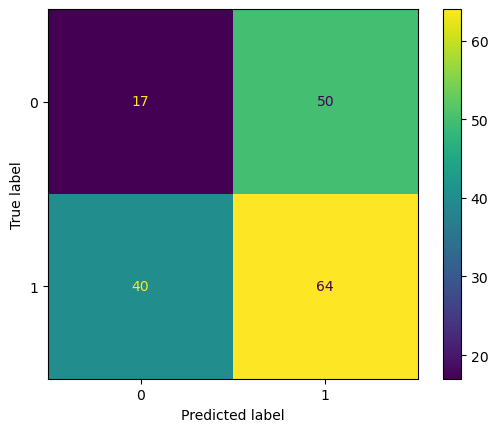

In [3]:
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay, precision_score, recall_score

p = y_train.mean()

np.random.seed(2024)
predictions = np.random.choice([0, 1], len(y_test), p=[1 - p, p])

ConfusionMatrixDisplay.from_predictions(y_test, predictions)

print(f'Baseline Precision: {precision_score(y_test, predictions):.2%}')
print(f'Baseline Recall:    {recall_score(y_test, predictions):.2%}')

The confusion matrix shows the baseline correctly identifies 65 malignant tumors (true positives) but also misclassifies 50 benign tumors as malignant (false positives) and misses 39 actual malignancies (false negatives). With precision of ~56% and recall of ~61%, this baseline performs only marginally better than chance, establishing a clear target for the logistic regression model.

## 3. Logistic Regression with L2 Regularization

Logistic regression is trained on a further train/validation split of the training data (70/30). An unregularized model (`penalty=None`) is first evaluated to check for overfitting. L2 regularization with varying `C` values is then explored; `C` controls regularization strength: smaller values apply stronger regularization.

The hyperparameter is selected on the **validation set only**. The test set is untouched until final evaluation.

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train, y_train, test_size=0.3, random_state=2024
)

# Unregularized baseline — check for overfitting
model_unreg = LogisticRegression(penalty=None, max_iter=1000)
model_unreg.fit(X_train_sub, y_train_sub)
print('No regularization')
print(f'  Train accuracy:      {accuracy_score(y_train_sub, model_unreg.predict(X_train_sub)):.4f}')
print(f'  Validation accuracy: {accuracy_score(y_val, model_unreg.predict(X_val)):.4f}\n')

# Sweep C values to find best regularization strength
for c in [0.1, 0.3, 0.5, 0.9, 1.1]:
    m = LogisticRegression(penalty='l2', max_iter=1000, C=c)
    m.fit(X_train_sub, y_train_sub)
    # print(f'  C={c}: train={accuracy_score(y_train_sub, m.predict(X_train_sub)):.4f}, val={accuracy_score(y_val, m.predict(X_val)):.4f}')

# Final model with C=0.9
model2 = LogisticRegression(penalty='l2', max_iter=1000, C=0.9)
model2.fit(X_train_sub, y_train_sub)
print('L2 regularization, C=0.9')
print(f'  Train accuracy:      {accuracy_score(y_train_sub, model2.predict(X_train_sub)):.4f}')
print(f'  Validation accuracy: {accuracy_score(y_val, model2.predict(X_val)):.4f}')

/opt/anaconda3/envs/ds_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/anaconda3/envs/ds_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_opti

No regularization
  Train accuracy:      0.9856
  Validation accuracy: 0.9417



/opt/anaconda3/envs/ds_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/anaconda3/envs/ds_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  wa

L2 regularization, C=0.9
  Train accuracy:      0.9712
  Validation accuracy: 0.9333


/opt/anaconda3/envs/ds_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/anaconda3/envs/ds_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  wa

The unregularized model shows a small but consistent gap between training and validation accuracy, indicating mild overfitting. Sweeping `C` values shows that `C=0.9` reduces this gap by ~1% while maintaining comparable overall accuracy. Stronger regularization (smaller C) hurt accuracy on both sets without closing the gap further.

## 4. Final Model Evaluation on Test Set

The regularized model (C=0.9) is evaluated on the held-out test set for the first and only time. Precision and recall are the primary metrics of interest in a clinical context.

Precision: 0.9345794392523364
Recall: 0.9615384615384616


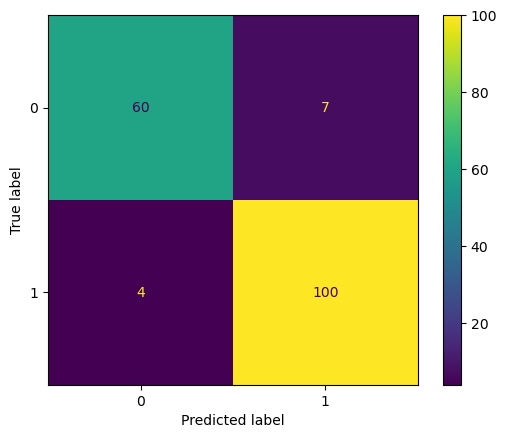

In [12]:
pred_test = model2.predict(X_test)

ConfusionMatrixDisplay.from_predictions(y_test, pred_test)

print(f'Precision: {precision_score(y_test, pred_test):.2%}')
print(f'Recall:    {recall_score(y_test, pred_test):.2%}')

The regularized logistic regression achieves **93% precision** and **96% recall** — a dramatic improvement over the random baseline (56% / 61%). Only 5 benign tumors are falsely flagged as malignant, and only 4 true malignancies are missed.

In clinical terms, recall is the more critical metric: a missed malignancy (false negative) poses far greater risk to a patient than a false alarm that triggers a follow-up exam.

## 5. ROC Curve Analysis

The ROC curve plots the true positive rate against the false positive rate across all possible decision thresholds. It reveals how the model would perform if a different operating point were chosen. For example, prioritizing maximum recall at the cost of more false alarms.

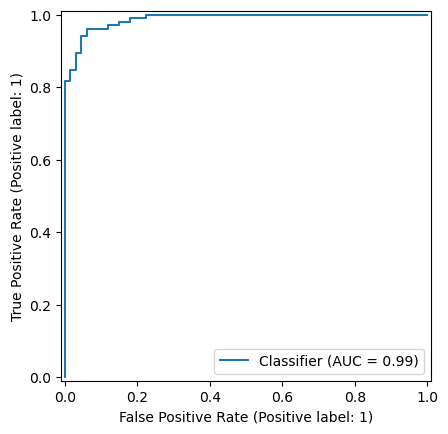

In [15]:
from sklearn.metrics import RocCurveDisplay

pred_prob_test = model2.predict_proba(X_test)
RocCurveDisplay.from_predictions(y_test, pred_prob_test[:, 1])

The ROC curve achieves an **AUC of 0.99**, indicating near-perfect discriminative ability across all thresholds. The default threshold (0.5) already yields excellent performance, but in cancer screening one might shift to a lower threshold to further maximize recall — accepting more false positives to ensure almost no malignancy goes undetected.

## 6. Interpretable Alternative: Shallow Decision Trees

While logistic regression is accurate, a clinician may want to understand *why* a prediction was made. Shallow decision trees are fully interpretable, each prediction can be traced through a small sequence of feature comparisons.

Three trees are compared at `max_depth` values of 3, 5, and 7, evaluated on the validation set.

Decision tree 1: Accuracy = 0.9166666666666666, Precision = 0.9078947368421053, Recall = 0.9583333333333334
Decision tree 2: Accuracy = 0.9, Precision = 0.9166666666666666, Recall = 0.9166666666666666
Decision tree 3: Accuracy = 0.8833333333333333, Precision = 0.9027777777777778, Recall = 0.9027777777777778


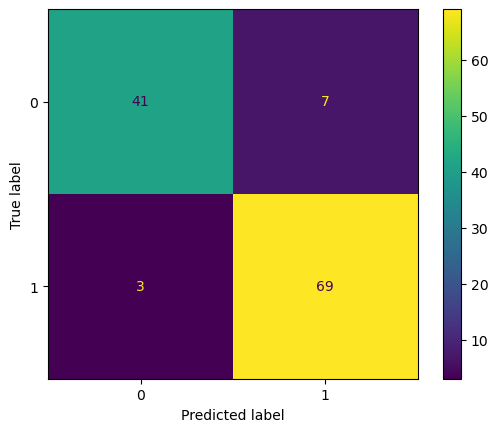

In [18]:
from sklearn.tree import DecisionTreeClassifier

for depth in [3, 5, 7]:
    dt = DecisionTreeClassifier(max_depth=depth)
    dt.fit(X_train_sub, y_train_sub)
    pred = dt.predict(X_val)
    print(f'max_depth={depth}: '
          f'accuracy={accuracy_score(y_val, pred):.4f}, '
          f'precision={precision_score(y_val, pred):.4f}, '
          f'recall={recall_score(y_val, pred):.4f}')

# Final chosen model: max_depth=3
dt_final = DecisionTreeClassifier(max_depth=3)
dt_final.fit(X_train_sub, y_train_sub)
ConfusionMatrixDisplay.from_predictions(y_val, dt_final.predict(X_val))

The shallowest tree (`max_depth=3`) achieves the best performance across all three metrics on the validation set and is also the simplest and most interpretable model. Deeper trees overfit without improving validation scores. The selected model (`max_depth=3`) provides a human-readable decision path that a clinician could follow and scrutinize.